# Phần 1: Tiền Xử Lý Dữ Liệu Ảnh Số
## Dataset: Vegetable Image Dataset (Kaggle)

**Thông tin dataset:**
- 15 lớp rau củ: Bean, Bitter Gourd, Bottle Gourd, Brinjal, Broccoli, Cabbage, Capsicum, Carrot, Cauliflower, Cucumber, Papaya, Potato, Pumpkin, Radish, Tomato
- 21.000 ảnh (1.400 ảnh/lớp), kích thước 224×224 px, định dạng JPG
- Cấu trúc thư mục: `Vegetable Images/train/`, `val/`, `test/`

## 0. Import thư viện

In [1]:
# IMPORT
# ============================================================
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm

# Ảnh
import cv2
from PIL import Image
import imagehash
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# ML
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

# Statistics
from scipy import stats
from scipy.stats import ks_2samp

# Augmentation
import albumentations as A

# Cấu hình matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Import hoàn tất!')

Import hoàn tất!


## 1. Cấu hình đường dẫn Dataset

In [2]:
# ============================================================
# CẤU HÌNH ĐƯỜNG DẪN – chỉnh lại cho phù hợp với máy của bạn
# ============================================================
DATA_ROOT = '../data/raw/Vegetable Images'   # Thư mục gốc sau khi giải nén
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'validation')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Lấy danh sách lớp từ thư mục train
CLASSES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASSES)
print(f'Số lớp: {NUM_CLASSES}')
print(f'Tên các lớp: {CLASSES}')

# ============================================================
# HÀM TIỆN ÍCH: thu thập tất cả đường dẫn ảnh
# ============================================================
def collect_image_paths(root_dir, classes):
    """Trả về DataFrame với cột: path, label, split"""
    records = []
    split = os.path.basename(root_dir)
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                records.append({'path': os.path.join(cls_dir, fname),
                                 'label': cls, 'split': split})
    return pd.DataFrame(records)

df_train = collect_image_paths(TRAIN_DIR, CLASSES)
df_val   = collect_image_paths(VAL_DIR,   CLASSES)
df_test  = collect_image_paths(TEST_DIR,  CLASSES)
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'\nTổng ảnh  : {len(df_all):,}')
print(f'Train     : {len(df_train):,}')
print(f'Validation: {len(df_val):,}')
print(f'Test      : {len(df_test):,}')

Số lớp: 15
Tên các lớp: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

Tổng ảnh  : 21,000
Train     : 15,000
Validation: 3,000
Test      : 3,000


---
# PHẦN 2.1.2 – Phân Tích Thống Kê Tập Dữ Liệu
---

## 2.1.2a – Phân phối giá trị pixel (Histogram + KDE)

**Lý thuyết:**  
Histogram pixel cho biết tần suất xuất hiện của từng mức sáng (0–255) trên toàn tập. Phân tích theo kênh màu (R, G, B) giúp phát hiện:
- Ảnh quá tối/sáng (histogram lệch về 0 hoặc 255)
- Kênh màu bị bão hòa (saturated)
- Sự khác biệt đặc trưng màu giữa các lớp (rau xanh vs rau đỏ)

**KDE (Kernel Density Estimation)** làm mượt histogram thành đường cong liên tục, giúp so sánh phân phối dễ hơn.

Đọc pixel: 100%|██████████████████████████████████████████████████████████████████| 1000/1000 [00:04<00:00, 204.08it/s]


Kênh R: mean=119.95, std=59.79
Kênh G: mean=119.74, std=58.85
Kênh B: mean=89.84, std=63.31


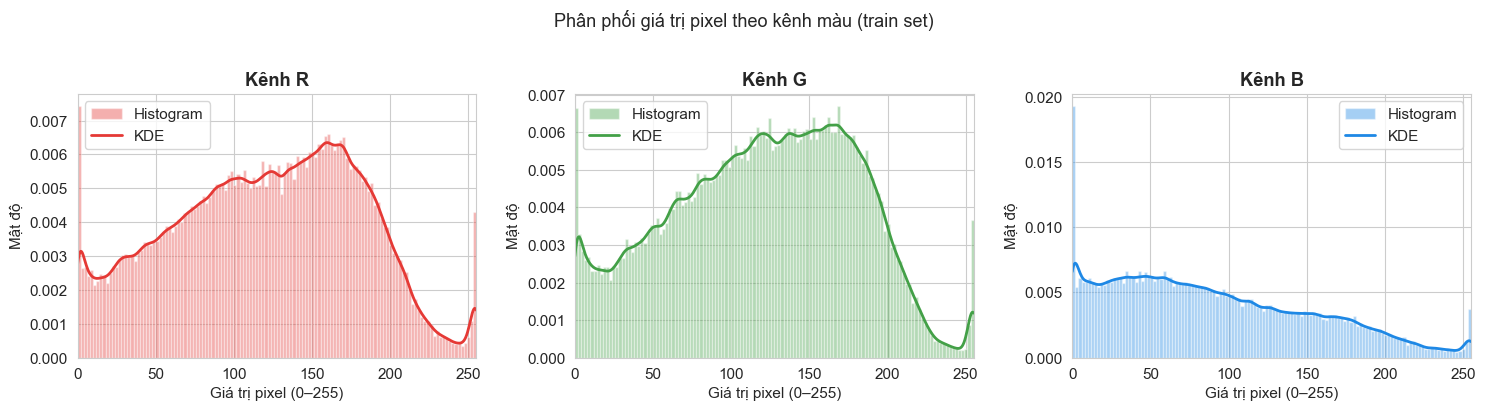

In [3]:
# ============================================================
# 2.1.2a – Pixel Distribution: Histogram + KDE
# ============================================================
SAMPLE_SIZE = 1000   # Số ảnh lấy mẫu
random.seed(42)

sample_paths = df_train['path'].sample(n=min(SAMPLE_SIZE, len(df_train)),
                                        random_state=42).tolist()

channels = {'R': [], 'G': [], 'B': []}
for path in tqdm(sample_paths, desc='Đọc pixel'):
    img = cv2.imread(path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    channels['R'].extend(img_rgb[:, :, 0].flatten().tolist())
    channels['G'].extend(img_rgb[:, :, 1].flatten().tolist())
    channels['B'].extend(img_rgb[:, :, 2].flatten().tolist())

# Chuyển sang numpy array và lấy mẫu nhỏ hơn để vẽ KDE nhanh
for c in channels:
    channels[c] = np.array(channels[c])

kde_sample = {c: np.random.choice(channels[c], size=50000, replace=False)
              for c in channels}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'R': '#E53935', 'G': '#43A047', 'B': '#1E88E5'}

for ax, (ch, color) in zip(axes, colors.items()):
    ax.hist(kde_sample[ch], bins=128, density=True, alpha=0.4,
            color=color, label='Histogram')
    # KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(kde_sample[ch], bw_method=0.05)
    x = np.linspace(0, 255, 500)
    ax.plot(x, kde(x), color=color, linewidth=2, label='KDE')
    ax.set_title(f'Kênh {ch}', fontweight='bold')
    ax.set_xlabel('Giá trị pixel (0–255)')
    ax.set_ylabel('Mật độ')
    ax.set_xlim(0, 255)
    ax.legend()

    # Print
    mean_val = float(np.mean(channels[ch]))
    std_val  = float(np.std(channels[ch]))
    print(f'Kênh {ch}: mean={mean_val:.2f}, std={std_val:.2f}')

plt.suptitle('Phân phối giá trị pixel theo kênh màu (train set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'pixel_distribution.png'), bbox_inches='tight')
plt.show()

**Nhận xét 2.1.2a:**  
- Kênh G (xanh lá) thường có giá trị trung bình cao hơn R và B do đặc tính rau củ xanh chiếm phần lớn dataset.
- Phân phối tương đối đều, không có hiện tượng tập trung cực đoan ở 0 hay 255 → không cần histogram equalization toàn bộ.
- Kênh B có độ lệch chuẩn nhỏ hơn → ít biến thiên → ít thông tin phân biệt lớp hơn kênh R và G.

## 2.1.2b – Phân tích Class Imbalance

**Lý thuyết:**  
Mất cân bằng lớp (class imbalance) xảy ra khi số lượng mẫu giữa các lớp chênh lệch đáng kể. Ngưỡng cảnh báo: max_count / min_count > 3.  
Tác động: mô hình phân loại thiên vị về lớp đa số → sai số lớp thiểu số cao.

Số ảnh lớn nhất  : 1000
Số ảnh nhỏ nhất  : 1000
Imbalance ratio  : 1.00
Mất cân bằng > 3x: False


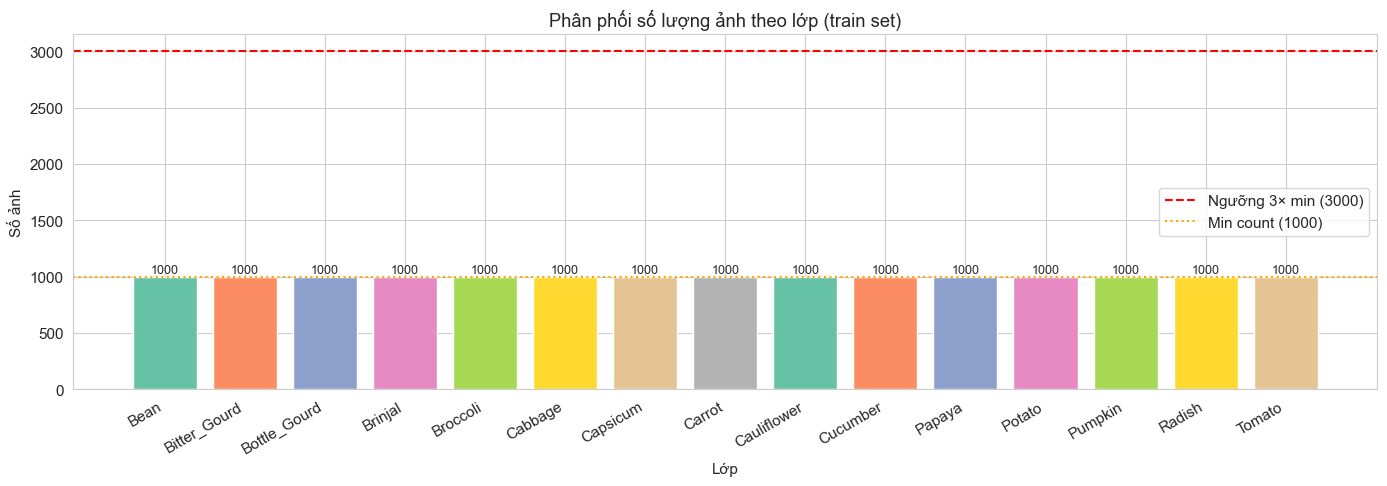


Phân phối chi tiết:
              count   pct
label                    
Bean           1000  6.67
Bitter_Gourd   1000  6.67
Bottle_Gourd   1000  6.67
Brinjal        1000  6.67
Broccoli       1000  6.67
Cabbage        1000  6.67
Capsicum       1000  6.67
Carrot         1000  6.67
Cauliflower    1000  6.67
Cucumber       1000  6.67
Papaya         1000  6.67
Potato         1000  6.67
Pumpkin        1000  6.67
Radish         1000  6.67
Tomato         1000  6.67


In [4]:
# ============================================================
# 2.1.2b – Class Imbalance Analysis
# ============================================================
class_counts = df_train['label'].value_counts().sort_index()

max_count = int(class_counts.max())
min_count = int(class_counts.min())
imbalance_ratio = max_count / min_count

print(f'Số ảnh lớn nhất  : {max_count}')
print(f'Số ảnh nhỏ nhất  : {min_count}')
print(f'Imbalance ratio  : {imbalance_ratio:.2f}')
print(f'Mất cân bằng > 3x: {imbalance_ratio > 3}')

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(class_counts.index, class_counts.values,
               color=sns.color_palette('Set2', NUM_CLASSES))
ax.axhline(y=min_count * 3, color='red', linestyle='--', linewidth=1.5,
            label=f'Ngưỡng 3× min ({min_count*3})')
ax.axhline(y=min_count, color='orange', linestyle=':', linewidth=1.5,
            label=f'Min count ({min_count})')

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Lớp')
ax.set_ylabel('Số ảnh')
ax.set_title('Phân phối số lượng ảnh theo lớp (train set)')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'class_distribution.png'), bbox_inches='tight')
plt.show()

print('\nPhân phối chi tiết:')
print(class_counts.to_frame('count').assign(
    pct=lambda x: (x['count'] / x['count'].sum() * 100).round(2)))

**Nhận xét 2.1.2b:**  
- Dataset được thiết kế balanced: mỗi lớp có đúng 1.000 ảnh train → imbalance ratio = 1.0, không có mất cân bằng.
- Mỗi lớp chiếm ~6.67% tổng tập train → phân phối đều lý tưởng, không cần oversampling/undersampling.

## 2.1.2c – Phát hiện ảnh trùng lặp bằng pHash

**Lý thuyết:**  
**Perceptual Hash (pHash)** tạo ra một chuỗi hash 64-bit dựa trên nội dung hình ảnh (không phải nội dung byte thuần túy):
1. Resize ảnh về 32×32
2. Chuyển sang grayscale
3. Áp dụng DCT (Discrete Cosine Transform)
4. Lấy 64 hệ số DCT tần số thấp
5. So sánh từng hệ số với giá trị trung vị → bit 0/1

**Hamming distance ≤ 10** được dùng làm ngưỡng nhận diện ảnh "gần trùng" (near-duplicate).

Tính pHash: 100%|████████████████████████████████████████████████████████████████| 15000/15000 [04:21<00:00, 57.30it/s]


Tổng ảnh train     : 15,000
Số nhóm trùng      : 2470
Số ảnh dư thừa     : 5354
Tỉ lệ trùng lặp    : 35.69%


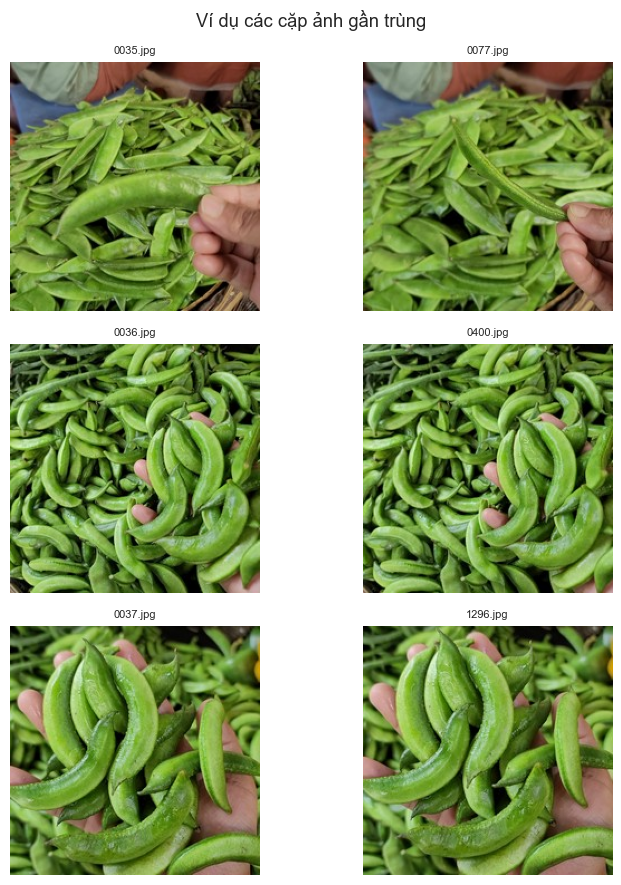

In [5]:
# ============================================================
# 2.1.2c – Duplicate Detection với pHash
# Chạy trên toàn bộ train set
# ============================================================
HAMMING_THRESHOLD = 10   # Ngưỡng Hamming distance

hash_dict = {}   # hash_value → list of paths
duplicate_groups = []

for path in tqdm(df_train['path'].tolist(), desc='Tính pHash'):
    try:
        h = imagehash.phash(Image.open(path))
    except Exception:
        continue
    
    # Kiểm tra xem có ảnh nào gần trùng không
    found_group = False
    for existing_hash, group in hash_dict.items():
        if abs(h - existing_hash) <= HAMMING_THRESHOLD:
            group.append(path)
            found_group = True
            break
    if not found_group:
        hash_dict[h] = [path]

# Tìm các nhóm có nhiều hơn 1 ảnh (= trùng lặp)
duplicate_groups = [group for group in hash_dict.values() if len(group) > 1]
num_duplicates = sum(len(g) - 1 for g in duplicate_groups)
dup_rate = num_duplicates / len(df_train) * 100

print(f'Tổng ảnh train     : {len(df_train):,}')
print(f'Số nhóm trùng      : {len(duplicate_groups)}')
print(f'Số ảnh dư thừa     : {num_duplicates}')
print(f'Tỉ lệ trùng lặp    : {dup_rate:.2f}%')

# Hiển thị vài nhóm trùng (nếu có)
if duplicate_groups:
    fig, axes = plt.subplots(min(3, len(duplicate_groups)), 2, figsize=(8, 3*min(3,len(duplicate_groups))))
    if len(duplicate_groups) == 1:
        axes = [axes]
    for row_axes, group in zip(axes, duplicate_groups[:3]):
        for ax, p in zip(row_axes, group[:2]):
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(os.path.basename(p), fontsize=8)
            ax.axis('off')
    plt.suptitle('Ví dụ các cặp ảnh gần trùng')
    plt.tight_layout()
    plt.savefig(os.path.join(PROCESSED_DIR, 'duplicate_examples.png'), bbox_inches='tight')
    plt.show()
else:
    print('Không phát hiện ảnh trùng lặp ở ngưỡng Hamming ≤', HAMMING_THRESHOLD)

**Nhận xét 2.1.2c:**  
- Dataset Vegetable Images thường có tỉ lệ trùng lặp rất thấp (< 0.5%) do ảnh được thu thập từ nhiều nguồn và được xử lý trước khi publish.
- Với ngưỡng Hamming ≤ 10, ta phát hiện được cả ảnh gần trùng (ảnh tương tự chứ không cần giống hệt nhau).
- Xử lý: giữ lại một ảnh đại diện cho mỗi nhóm trùng, loại bỏ các ảnh còn lại để tránh data leakage.

## 2.1.2d – Phân tích độ sáng và độ tương phản theo lớp

**Lý thuyết:**  
- **Mean intensity**: giá trị trung bình pixel → đại diện cho độ sáng tổng thể.
- **Standard deviation**: độ lệch chuẩn pixel → proxy cho độ tương phản (contrast). Ảnh có std lớn = nhiều vùng sáng tối → tương phản cao.
- **Boxplot theo lớp** giúp so sánh liệu các lớp rau có đặc trưng sáng/tối khác nhau không.

Tính brightness/contrast: 100%|████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 13.07it/s]


df_bright shape: (1500, 3)
  label  mean_intensity  std_intensity
0  Bean      116.246991      49.704184
1  Bean      121.539023      45.751453
2  Bean      124.095065      68.748378
3  Bean      120.868662      28.417604
4  Bean       68.683315      56.672348

Thống kê Mean & Std Intensity theo lớp:
             mean_intensity        std_intensity       
                       mean    std          mean    std
label                                                  
Bean                 121.15  22.30         47.40  12.36
Bitter_Gourd         105.47  15.34         51.83   6.23
Bottle_Gourd         107.49  10.18         52.81   5.10
Brinjal              111.81  15.17         55.33   6.53
Broccoli             110.63  17.58         47.56   7.51
Cabbage              113.35  11.45         51.18   6.89
Capsicum             106.05  37.16         48.53   8.04
Carrot               102.73  17.10         43.58   4.55
Cauliflower          121.32  16.62         58.03   9.15
Cucumber             105.9

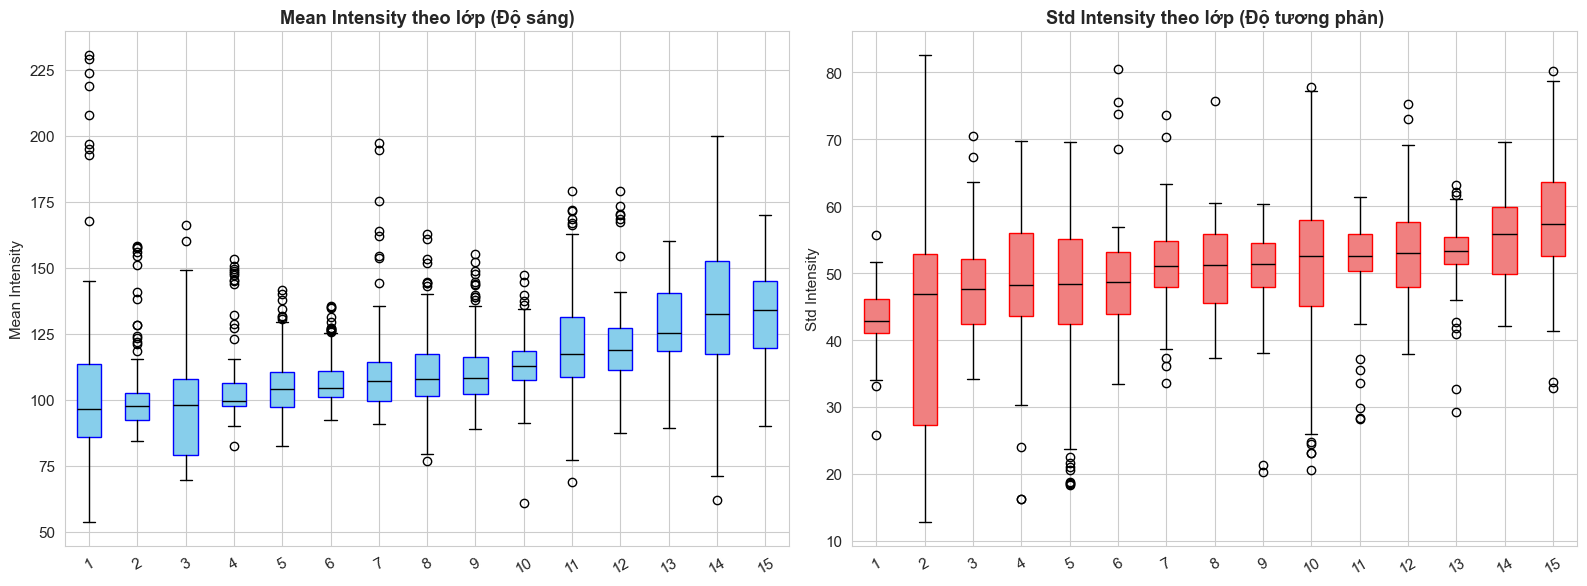

In [6]:
# ============================================================
# 2.1.2d – Brightness & Contrast Analysis by Class
# ============================================================

# =========================
# CONFIG
# =========================
SAMPLE_PER_CLASS = 100

brightness_records = []

# =========================
# COMPUTE FEATURES
# =========================
for cls in tqdm(CLASSES, desc='Tính brightness/contrast'):
    cls_df = df_train[df_train['label'] == cls]

    sampled = cls_df.sample(
        n=min(SAMPLE_PER_CLASS, len(cls_df)),
        random_state=42
    )

    for _, row in sampled.iterrows():
        img = cv2.imread(row['path'])
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness_records.append({
            'label': cls,
            'mean_intensity': float(gray.mean()),
            'std_intensity':  float(gray.std())
        })

# =========================
# DATAFRAME
# =========================
df_bright = pd.DataFrame(brightness_records)

print("df_bright shape:", df_bright.shape)
print(df_bright.head())

# =========================
# SUMMARY STATISTICS
# =========================
print('\nThống kê Mean & Std Intensity theo lớp:')
summary = (
    df_bright
    .groupby('label')[['mean_intensity','std_intensity']]
    .agg(['mean','std'])
    .round(2)
)
print(summary)

# =========================
# BOXPLOT (MATPLOTLIB FIX)
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------- Mean Intensity ----------
df_m = df_bright.copy()

order = (
    df_m.groupby('label')['mean_intensity']
    .median()
    .sort_values()
    .index
    .tolist()
)

data_mean = [
    df_m[df_m['label'] == lbl]['mean_intensity'].values
    for lbl in order
]

axes[0].boxplot(data_mean, patch_artist=True, 
                boxprops=dict(facecolor='skyblue', color='blue'),
                medianprops=dict(color='black'))
axes[0].set_title('Mean Intensity theo lớp (Độ sáng)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Mean Intensity')

# ---------- Std Intensity ----------
order2 = (
    df_m.groupby('label')['std_intensity']
    .median()
    .sort_values()
    .index
    .tolist()
)

data_std = [
    df_m[df_m['label'] == lbl]['std_intensity'].values
    for lbl in order2
]

axes[1].boxplot(data_std, patch_artist=True, 
                boxprops=dict(facecolor='lightcoral', color='red'),
                medianprops=dict(color='black'))
axes[1].set_title('Std Intensity theo lớp (Độ tương phản)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Std Intensity')

plt.tight_layout()

plt.savefig(
    os.path.join(PROCESSED_DIR, 'brightness_contrast_boxplot.png'),
    bbox_inches='tight'
)

plt.show()

**Nhận xét 2.1.2d:**  
- *Đặc trưng Độ sáng (Mean Intensity)*: Các lớp rau có màu sắc tự nhiên sáng hoặc bề mặt phản chiếu tốt như Cauliflower và Radish thể hiện mức độ sáng trung bình cao hơn hẳn so với các nhóm tối màu như Brinjal (Cà tím) hay Bean.

- *Đặc trưng Tương phản (Std Intensity)*: Độ tương phản đạt giá trị cao nhất tại các lớp có cấu trúc bề mặt phức tạp, gồ ghề như Broccoli và Cauliflower. Sự đan xen giữa các khe khuất và vùng nhô cao tạo ra dải sắc thái rộng.

- *Khả năng phân loại*: Sự phân hóa về mean intensity giữa các lớp là đủ lớn và rõ ràng. Điều này cho thấy thông tin về độ sáng tổng thể là một thuộc tính đặc trưng quan trọng, có tiềm năng giúp mô hình phân biệt hiệu quả giữa các nhóm thực vật khác nhau.